In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from itertools import combinations
from scipy.stats import ttest_ind_from_stats
import os

In [2]:
df = pd.read_csv("convlstm_results.csv")
df.head()

,huc12,huc8,snow_type,mse,kge
0,170103020101,17010302,Montane Forest,3229.549654,0.856647
1,170103020102,17010302,Montane Forest,2798.650342,0.841030
2,170103020103,17010302,Montane Forest,4021.845848,0.876558
3,170103020201,17010302,Montane Forest,2533.370419,0.896791
4,170103020202,17010302,Montane Forest,1537.137868,0.816862


In [4]:
df['kge'].mean()

0.5894246428417116

In [3]:
df.groupby("snow_type").agg(
    num_hucs=("huc12", "count"),
    mse_mean=("mse", "mean"),
    mse_std=("mse", "std"),
    rmse_mean=("mse", lambda x: np.sqrt(np.mean(x))),
    rmse_std=("mse", lambda x: np.std(np.sqrt(x)))
).reset_index()

,snow_type,num_hucs,mse_mean,mse_std,rmse_mean,rmse_std
0,Boreal Forest,1,41705.368068,NaN,204.218922,0.000000
1,Ephemeral,180,903.086067,3057.246087,30.051390,21.533980
2,Maritime,154,71495.305674,68633.050043,267.386061,125.461663
3,Montane Forest,185,4564.331693,7806.779253,67.559838,37.228389
4,Prairie,11,2560.333760,4293.340575,50.599741,32.342443


In [4]:
df.groupby("huc8").agg(
    rmse=("mse", lambda x: np.sqrt(np.mean(x))),
    kge=("kge","mean"),
    num_hucs=("huc12","count")
).sort_values("kge", ascending=False)

,rmse,kge,num_hucs
huc8,,,
17060207,42.020225,0.882981,51
17010302,48.654117,0.867922,8
17010304,55.955679,0.836987,52
17060208,88.640081,0.758661,44
17020010,79.959453,0.682159,41
17030001,103.168316,0.666978,52
17030002,126.878088,0.626124,29
17020011,230.356534,0.558937,43
17020009,218.914527,0.500350,29


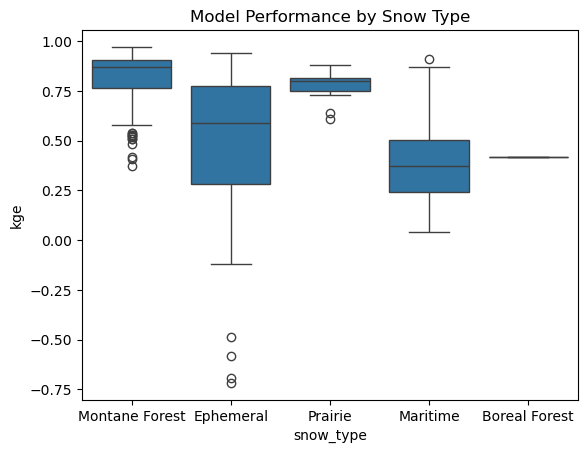

In [5]:
sns.boxplot(data=df, x="snow_type", y="kge")
plt.title("Model Performance by Snow Type")
plt.show()

In [6]:
grouped_counts = df.groupby('huc8')['snow_type'].value_counts()
print(grouped_counts)

huc8      snow_type     
17010302  Montane Forest     8
17010304  Montane Forest    35
          Ephemeral         16
          Prairie            1
17020009  Maritime          18
          Ephemeral          5
          Montane Forest     5
          Boreal Forest      1
17020010  Ephemeral         24
          Montane Forest    10
          Prairie            4
          Maritime           3
17020011  Maritime          28
          Montane Forest     8
          Ephemeral          7
17030001  Ephemeral         27
          Montane Forest    12
          Maritime          11
          Prairie            2
17030002  Maritime          12
          Montane Forest    11
          Ephemeral          6
17030003  Ephemeral         67
          Montane Forest     4
          Prairie            1
17060207  Montane Forest    50
          Ephemeral          1
17060208  Montane Forest    41
          Prairie            3
17110005  Maritime          38
          Ephemeral          2
          Mont

In [7]:
def extract_subdict(original_dict, keys_to_extract):
    return {key: original_dict[key] for key in keys_to_extract if key in original_dict}

# Step 2 - Define Plotting And Analytics Functions 

In [8]:
def plot_scatter(df, x_var_name, y_var_name, color_map, col="snow_type", title="Scatter_Plot", save_local=False, show_legend=True):
    """
    Creates a scatter plot of specified x and y variables, colored by Predominant Snow Type.

    Parameters:
    - df: DataFrame containing the x and y variables and "color_snow_type" column.
    - x_var_name: Column name for the x-axis variable.
    - y_var_name: Column name for the y-axis variable.
    - color_map: Dictionary mapping labels to their respective colors for the legend.
    - title: Title of the plot (default: "Scatter Plot" with underscores).
    - save_local: If True, saves the plot as a PNG file.
    - show_legend: If True, shows the legend (default is True).
    """
    plt.figure(figsize=(10, 6))

    colors = df[col].map(color_map)
    colors = colors.fillna("gray")

    plt.scatter(df[x_var_name], df[y_var_name], c=colors, alpha=0.7, edgecolors="k")

    # Add labels and title
    plt.xlabel(x_var_name.replace("_", " "))
    plt.ylabel(y_var_name.replace("_", " "))
    plt.title(title.replace("_", " "))

    # Show legend if show_legend is True
    if show_legend:
        handles = [plt.Line2D([0], [0], marker='o', color=color, markersize=8, label=label) 
               for label, color in color_map.items()]
        handles.append(
            plt.Line2D([0], [0], marker='o', color="gray",
                       linestyle='None', markersize=8, label="Other")
        )
        plt.legend(handles=handles, title="Predominant Snow Type", loc='lower right', bbox_to_anchor=(0.95, 0.05))

    # Show or save plot
    if save_local:
        plt.savefig(f"charts/{title}.png", bbox_inches='tight')

    plt.show()




In [9]:
def plot_scatter_w_R2(df, x_var_name, y_var_name, color_map, title="Scatter_Plot", save_local=True, show_legend=True):
    """
    Creates a scatter plot of specified x and y variables, colored by Predominant Snow Type.
    Adds a best-fit line and displays the R-squared value.

    Parameters:
    - df: DataFrame containing the x and y variables and "Snow_Type_Color" column.
    - x_var_name: Column name for the x-axis variable.
    - y_var_name: Column name for the y-axis variable.
    - color_map: Dictionary mapping labels to their respective colors for the legend.
    - title: Title of the plot (default: "Scatter Plot" with underscores).
    - save_local: If True, saves the plot as a PNG file.
    - show_legend: If True, shows the legend (default is True).
    """
    plt.figure(figsize=(10, 6))

    # Use colors directly from the dataframe, default to white if missing
    colors = df["color_snow_type"].fillna("white")

    plt.scatter(df[x_var_name], df[y_var_name], c=colors, alpha=0.7, edgecolors="k", label="Data Points")

    # Compute best-fit line
    x_values = df[x_var_name].values.reshape(-1, 1)
    y_values = df[y_var_name].values

    model = LinearRegression()
    model.fit(x_values, y_values)
    y_pred = model.predict(x_values)

    # Compute R-squared
    r2 = r2_score(y_values, y_pred)

    # Plot best-fit line
    plt.plot(df[x_var_name], y_pred, color="red", linestyle="--", linewidth=2, label=f"Best Fit Line (R²={r2:.2f})")

    # Add labels and title
    plt.xlabel(x_var_name.replace("_", " "))
    plt.ylabel(y_var_name.replace("_", " "))
    plt.title(title.replace("_", " "))

    # Annotate with R-squared value
    plt.text(0.05, 0.9, f"R² = {r2:.2f}", transform=plt.gca().transAxes, fontsize=12, color="red", bbox=dict(facecolor="white", alpha=0.7))

    # Show legend if show_legend is True
    if show_legend:
        handles = [plt.Line2D([0], [0], marker='o', color=color, markersize=8, label=label) 
               for label, color in color_map.items()]
        plt.legend(handles=handles, title="Predominant Snow Type", loc='lower right', bbox_to_anchor=(0.95, 0.05))


    # Show or save plot
    if save_local:
        plt.savefig(f"charts/{title}.png", bbox_inches='tight')

    plt.show()


In [10]:
def plot_boxplot_by_group(df, parameter, title, groupby_column, color_map=None, category_order=None, trunc=False, save_local=False):
    """
    Plot a boxplot for the given parameter grouped by a specified column.
    Parameters:
    - df: DataFrame containing the data.
    - parameter: The name of the parameter to be plotted (as a column in the DataFrame).
    - title: The title of the plot.
    - groupby_column: The column by which to group the data.
    - color_map: A dictionary mapping categories to colors. Defaults to None.
    - category_order: Optional list of categories in the desired order for plotting.
    - trunc: If True, rotates labels 90 degrees and truncates them to 15 characters.
    - save_local: If True, saves the plot as a PNG file in the 'charts/' directory.
    """

    grouped_data = df.groupby(groupby_column)[parameter].agg(['count', 'median', 'mean', 'std'])

    # Define a default color map if none is provided
    if color_map is None:
        default_palette = sns.color_palette("twilight", len(df[groupby_column].unique()))
        color_map = dict(zip(sorted(df[groupby_column].astype(str).unique()), default_palette))
        
    # If category_order is not provided, use the keys of the color_map in order
    if category_order is None:
        category_order = list(color_map.keys())

    # Create the boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=groupby_column, y=parameter, palette=color_map, order=category_order)

    # Set the title and labels
    plt.title(title)
    plt.xlabel(groupby_column)
    plt.ylabel(parameter)

    # Adjust x-axis labels based on truncation
    if trunc:
        plt.xticks(rotation=90)  # Rotate labels 90 degrees
    else:
        plt.xticks(rotation=0)  # Keep labels horizontal

    # Ensure layout is clean
    plt.tight_layout()

    # Save the plot locally if save_local is True
    if save_local:
        os.makedirs("charts", exist_ok=True)  # Ensure the directory exists
        safe_title = "".join(c if c.isalnum() or c in (" ", "-", "_") else "_" for c in title)  # Remove invalid filename characters
        plt.savefig(f"charts/{safe_title}.png", bbox_inches='tight')

    # Show the plot
    plt.show()

    return grouped_data

In [11]:
def pairwise_welch_t_test(grouped_data):
    """
    Performs Welch's t-test for unequal variances on all pairwise comparisons 
    of groups in grouped_data.

    Parameters:
    - grouped_data: DataFrame with a 'mean' and 'std' column, indexed by group.

    Returns:
    - A DataFrame with columns "Group1", "Group2", and "P-Value".
    """
    results = []

    # Get unique groups
    groups = grouped_data.index

    # Perform pairwise Welch's t-test
    for group1, group2 in combinations(groups, 2):
        # Extract data for each group
        mean1, std1, n1 = grouped_data.loc[group1, ['mean', 'std', 'count']]
        mean2, std2, n2 = grouped_data.loc[group2, ['mean', 'std', 'count']]

        # Compute Welch's t-test
        t_stat, p_value = ttest_ind_from_stats(mean1, std1, n1, mean2, std2, n2, equal_var=False)

        # Append results as a row in the list
        results.append({'Group1': group1, 'Group2': group2, 'P-Value': p_value})

    # Convert the results list to a DataFrame
    return pd.DataFrame(results)



In [12]:

def plot_boxplot_by_2group(df, parameter, title, groupby_column_1, groupby_column_2, color_map=None, category_order=None, trunc=False, save_local=False):
    """
    Plot a boxplot for the given parameter grouped by two specified columns.
    
    Parameters:
    - df: DataFrame containing the data.
    - parameter: The name of the parameter to be plotted (as a column in the DataFrame).
    - title: The title of the plot.
    - groupby_column_1: The first column by which to group the data (determines left-to-right order).
    - groupby_column_2: The second column for creating side-by-side box plots within each group of groupby_column_1.
    - color_map: A dictionary mapping groupby_column_2 categories to colors. Defaults to None.
    - category_order: Optional list of categories in the desired order for plotting groupby_column_1.
    - trunc: If True, rotates labels 90 degrees and truncates them to 15 characters.
    - save_local: If True, saves the plot as a PNG file in the 'charts/' directory.
    """
    
    # Define a default color map if none is provided
    if color_map is None:
        unique_categories = sorted(df[groupby_column_2].unique())
        default_palette = sns.color_palette("twilight", len(unique_categories))
        color_map = dict(zip(unique_categories, default_palette))

    # If category_order is not provided, use the sorted unique values from groupby_column_1
    if category_order is None:
        category_order = sorted(df[groupby_column_1].unique())

    # Apply truncation if enabled
    if trunc:
        category_order = [cat[:15] for cat in category_order]

    # Create the boxplot
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=groupby_column_1, y=parameter, hue=groupby_column_2, 
                palette=color_map, order=category_order, dodge=True)

    # Set the title and labels
    plt.title(title)
    plt.xlabel(groupby_column_1)
    plt.ylabel(parameter)

    # Adjust x-axis labels based on truncation
    if trunc:
        plt.xticks(rotation=90)  # Rotate labels 90 degrees
    else:
        plt.xticks(rotation=0)  # Keep labels horizontal

    # Move the legend outside the plot for better visibility
    plt.legend(title=groupby_column_2, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ensure layout is clean
    plt.tight_layout()

    # Save the plot locally if save_local is True
    if save_local:
        os.makedirs("charts", exist_ok=True)  # Ensure the directory exists
        safe_title = "".join(c if c.isalnum() or c in (" ", "-", "_") else "_" for c in title)  # Remove invalid filename characters
        plt.savefig(f"charts/{safe_title}.png", bbox_inches='tight')

    # Show the plot
    plt.show()

In [13]:
color_map_snow = {
    "Ephemeral": "#E6E6FA",
    "Maritime": "blue",
    "Montane Forest": "darkgreen",
    "Prairie": "lightgreen",
    "Boreal Forest": "yellow",
}

# Step 3 Create ScatterPlots

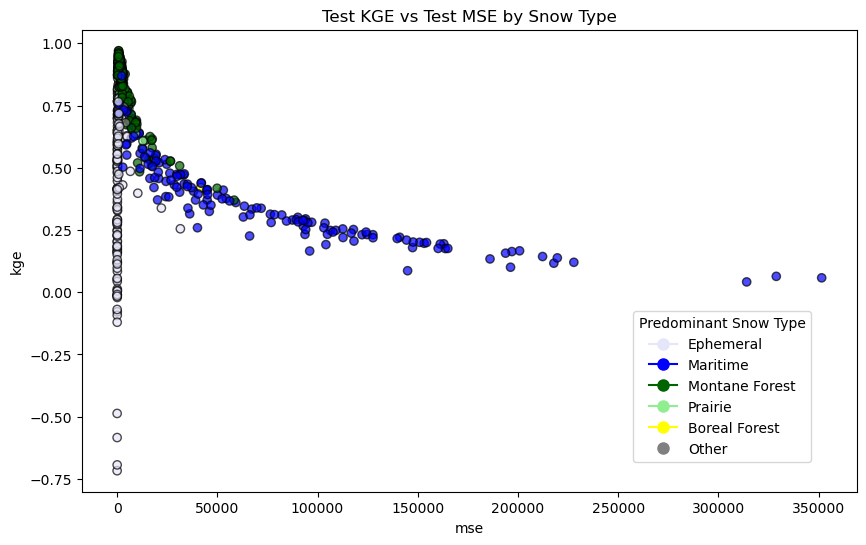

In [14]:
# All results 
y_var = "Test KGE"
x_var = "Test MSE"
ttl = f"{y_var}_vs_{x_var}_by_Snow_Type"
plot_scatter(df, "mse", "kge", color_map_snow, title = ttl)

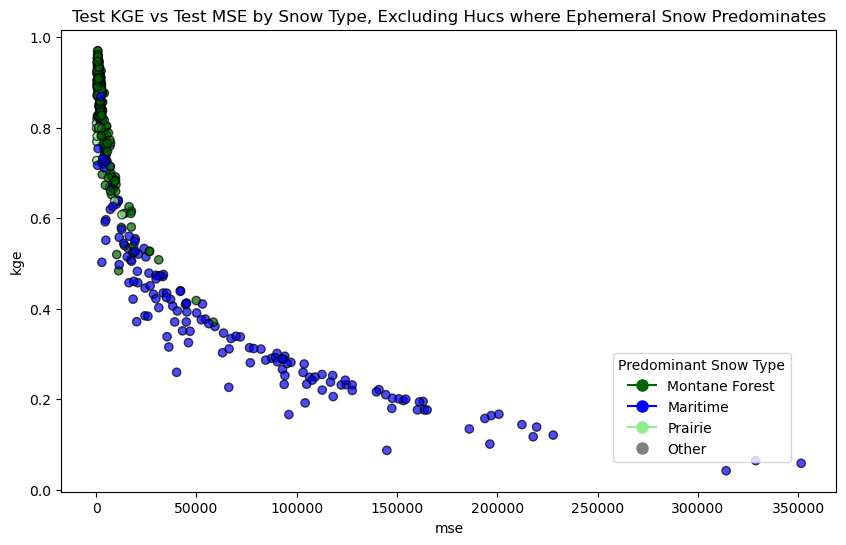

In [15]:
df_noE = df[
    (df["snow_type"] != "Ephemeral") &
    (df["snow_type"] != "Boreal Forest") &
    (df["snow_type"].notna())
].copy()

color_map = extract_subdict(color_map_snow, ["Montane Forest", "Maritime", "Prairie"])

y_var = "Test KGE"
x_var = "Test MSE"
ttl = f"{y_var}_vs_{x_var}_by_Snow_Type, Excluding Hucs where Ephemeral Snow Predominates"

plot_scatter(df_noE, "mse", "kge", color_map, col="snow_type", title=ttl)

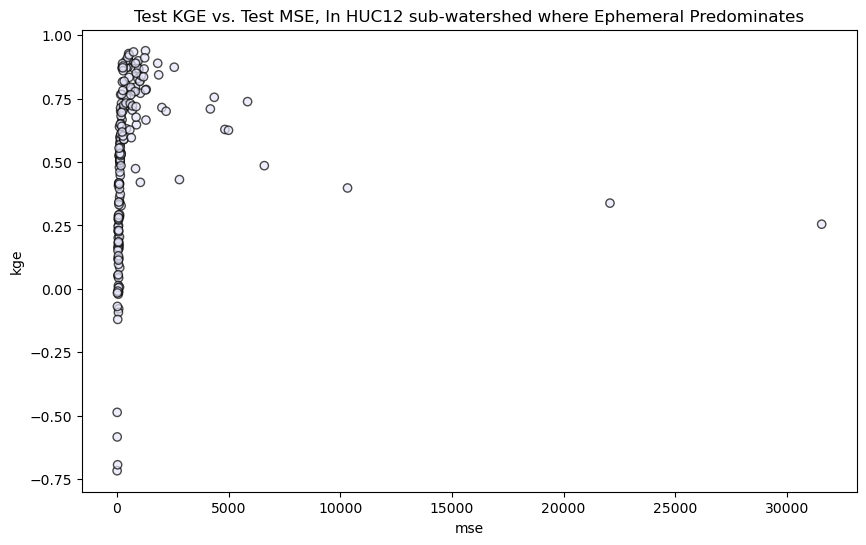

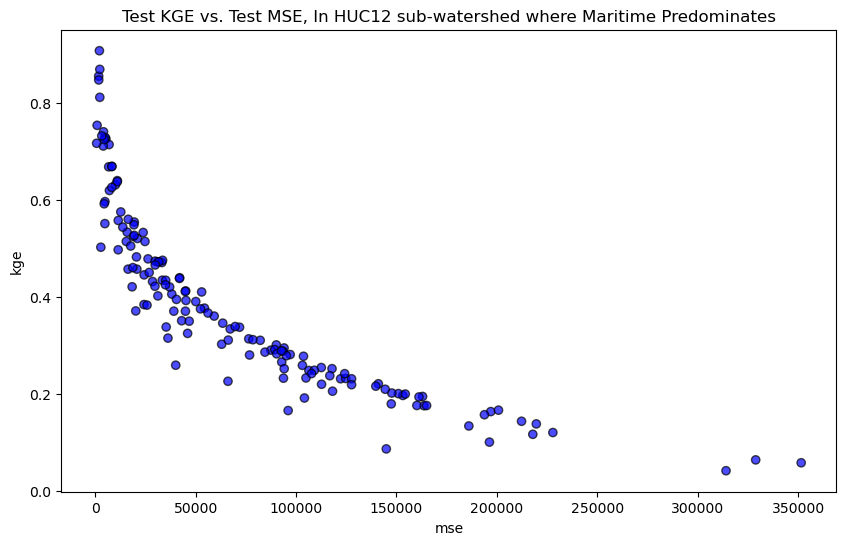

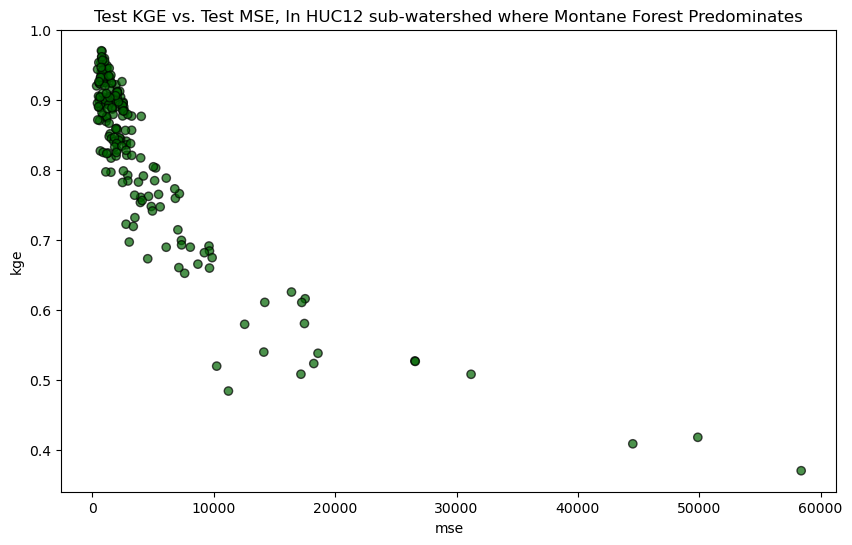

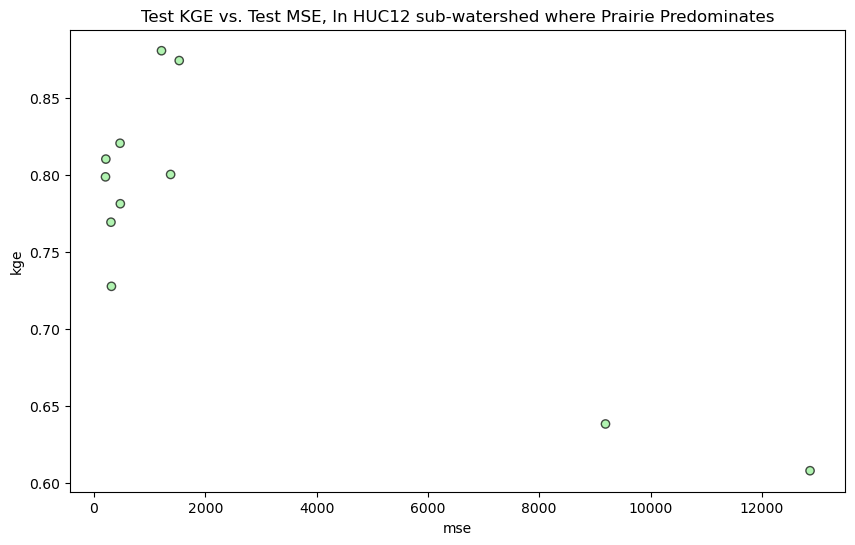

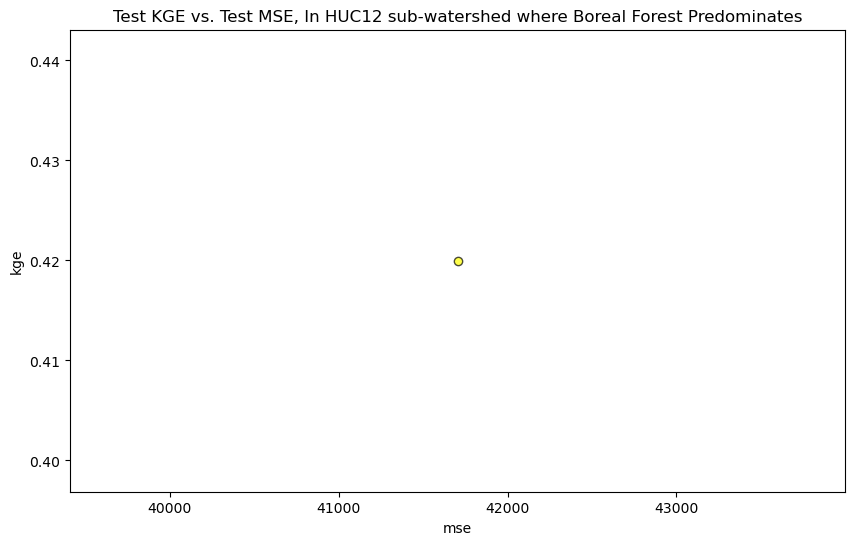

In [16]:
# Scatterlot by snowtype 
for snowtype in color_map_snow.keys():
    df_st = df[df["snow_type"] == snowtype]
    ttl = f"Test KGE vs. Test MSE, In HUC12 sub-watershed where {snowtype} Predominates"
    plot_scatter(df_st, "mse", "kge", color_map_snow, title = ttl, show_legend = False)


In [17]:
# Exclude Prarie and Boreal sub, hucs.  Optionally exclude Ephemeral 
snow_types_to_include = ["Montane Forest", "Ephemeral", "Maritime"]
filtered_df = df[df["snow_type"].isin(snow_types_to_include)]

snow_types_to_include_noE = ["Montane Forest", "Maritime"]
filtered_df_noE = df[df["snow_type"].isin(snow_types_to_include_noE)]

/tmp/ipykernel_61501/976335912.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_column, y=parameter, palette=color_map, order=category_order)


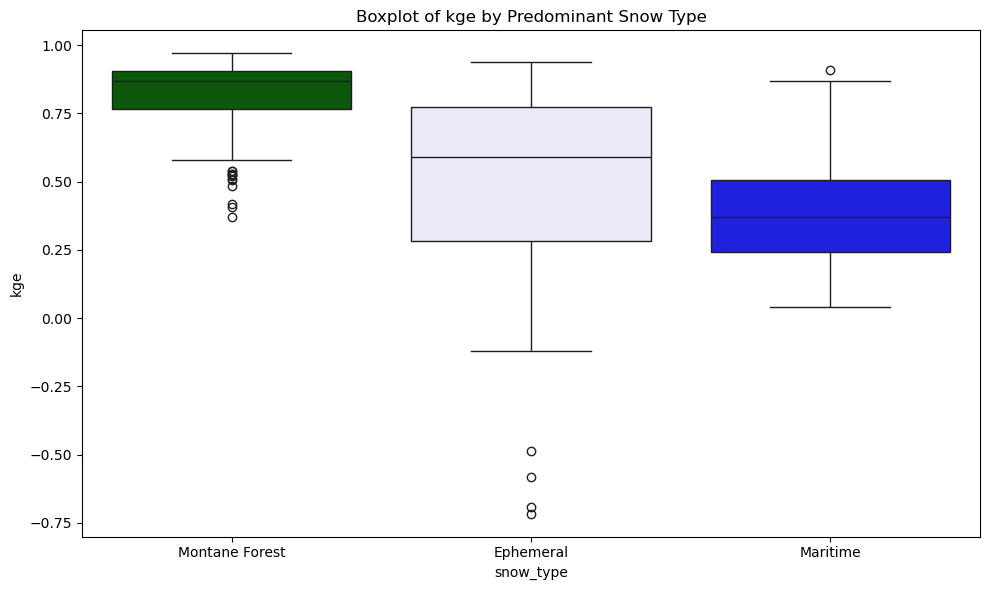

P-values :      Group1          Group2       P-Value
0  Ephemeral        Maritime  5.301484e-05
1  Ephemeral  Montane Forest  8.350833e-26
2   Maritime  Montane Forest  7.167485e-69


,count,median,mean,std
snow_type,,,,
Ephemeral,180,0.58920,0.508213,0.330974
Maritime,154,0.37061,0.389386,0.188291
Montane Forest,185,0.86922,0.822214,0.124886


In [18]:
group_by = "snow_type"
parameter = "kge"
color_map = extract_subdict(color_map_snow, snow_types_to_include)
ttl = f"Boxplot of {parameter} by Predominant Snow Type"
grouped_data = plot_boxplot_by_group(filtered_df, parameter, title= ttl, groupby_column = group_by, color_map = color_map)
p_values = pairwise_welch_t_test(grouped_data)
print(f"P-values :{p_values}")
grouped_data

/tmp/ipykernel_61501/976335912.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_column, y=parameter, palette=color_map, order=category_order)


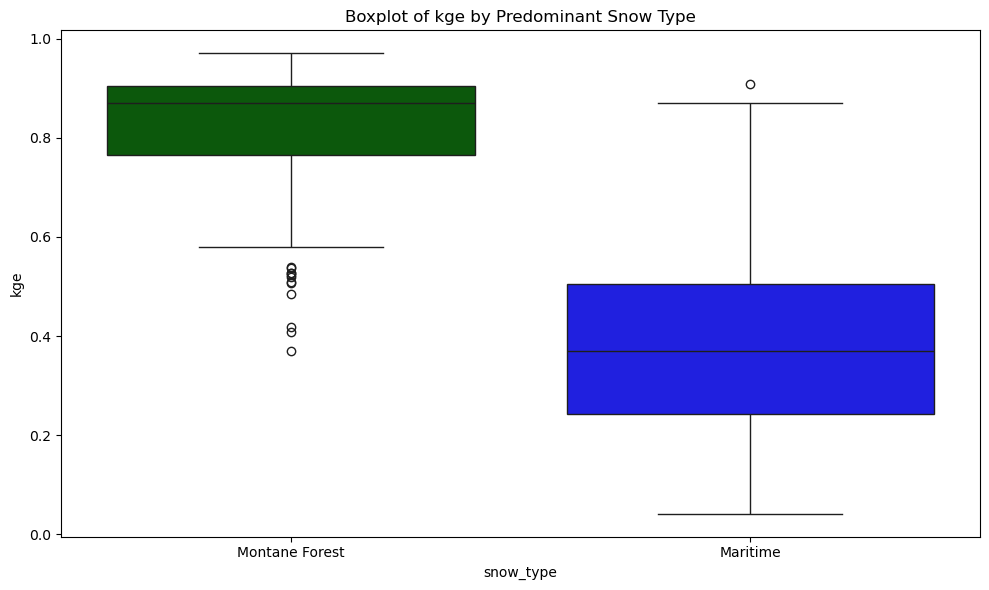

P-values :     Group1          Group2       P-Value
0  Maritime  Montane Forest  7.167485e-69


,count,median,mean,std
snow_type,,,,
Maritime,154,0.37061,0.389386,0.188291
Montane Forest,185,0.86922,0.822214,0.124886


In [19]:
parameter = "kge"
color_map = extract_subdict(color_map_snow, snow_types_to_include_noE)
ttl = f"Boxplot of {parameter} by Predominant Snow Type"
grouped_data = plot_boxplot_by_group(filtered_df_noE, parameter, title= ttl, groupby_column = group_by, color_map = color_map)
p_values = pairwise_welch_t_test(grouped_data)
print(f"P-values :{p_values}")
grouped_data

/tmp/ipykernel_61501/976335912.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_column, y=parameter, palette=color_map, order=category_order)


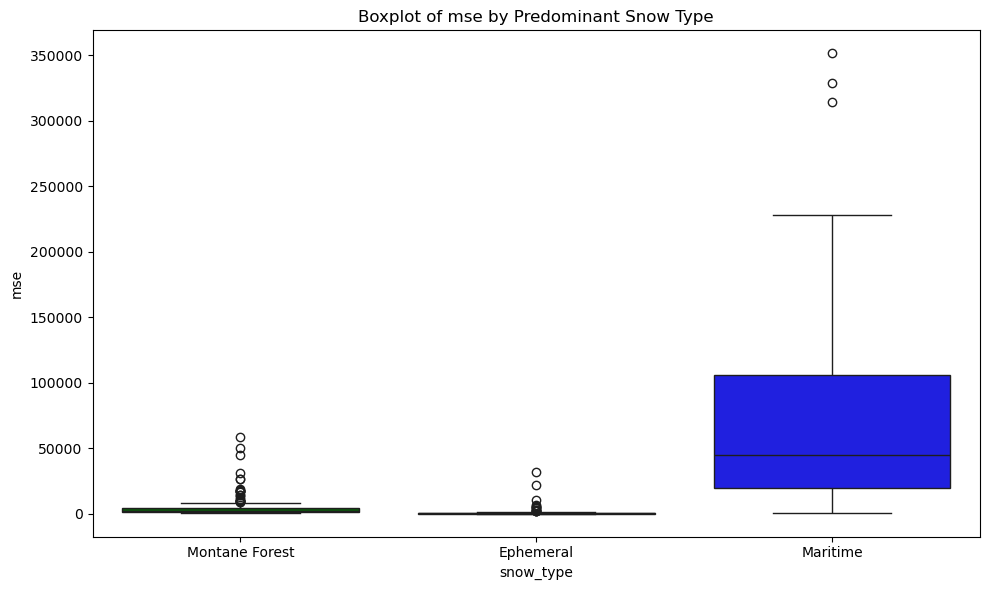

P-values :      Group1          Group2       P-Value
0  Ephemeral        Maritime  7.360891e-26
1  Ephemeral  Montane Forest  1.054197e-08
2   Maritime  Montane Forest  4.967750e-24


,count,median,mean,std
snow_type,,,,
Ephemeral,180,181.223099,903.086067,3057.246087
Maritime,154,45119.563317,71495.305674,68633.050043
Montane Forest,185,2040.387490,4564.331693,7806.779253


In [20]:
parameter = "mse"
color_map = extract_subdict(color_map_snow, snow_types_to_include)
ttl = f"Boxplot of {parameter} by Predominant Snow Type"
grouped_data = plot_boxplot_by_group(filtered_df, parameter, title= ttl, groupby_column = group_by, color_map = color_map)
p_values = pairwise_welch_t_test(grouped_data)
print(f"P-values :{p_values}")
grouped_data

/tmp/ipykernel_61501/976335912.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_column, y=parameter, palette=color_map, order=category_order)


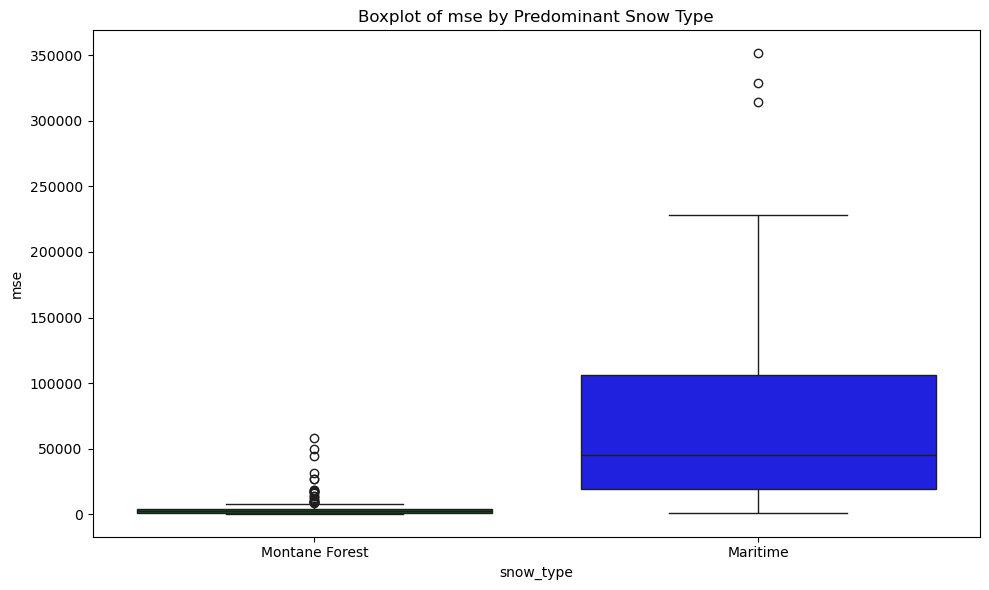

P-values :     Group1          Group2       P-Value
0  Maritime  Montane Forest  4.967750e-24


,count,median,mean,std
snow_type,,,,
Maritime,154,45119.563317,71495.305674,68633.050043
Montane Forest,185,2040.387490,4564.331693,7806.779253


In [21]:
parameter = "mse"
color_map = extract_subdict(color_map_snow, snow_types_to_include_noE)
ttl = f"Boxplot of {parameter} by Predominant Snow Type"
grouped_data = plot_boxplot_by_group(filtered_df_noE, parameter, title= ttl, groupby_column = group_by, color_map = color_map)
p_values = pairwise_welch_t_test(grouped_data)
print(f"P-values :{p_values}")
grouped_data

# Step 6 Examine by Basin

In [22]:
aggregated_df_KGE = (
    filtered_df_noE.groupby("huc8", as_index=False)["kge"]
    .median()
    .sort_values(by="kge", ascending=False)
    .reset_index()
)
aggregated_df_KGE


,index,huc8,kge
0,8,17060207,0.905694
1,1,17010304,0.889728
2,7,17030003,0.887282
3,3,17020010,0.879289
4,0,17010302,0.872889
5,9,17060208,0.782045
6,5,17030001,0.673050
7,12,17110007,0.596543
8,6,17030002,0.532919
9,13,17110008,0.502497


/tmp/ipykernel_61501/976335912.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_column, y=parameter, palette=color_map, order=category_order)


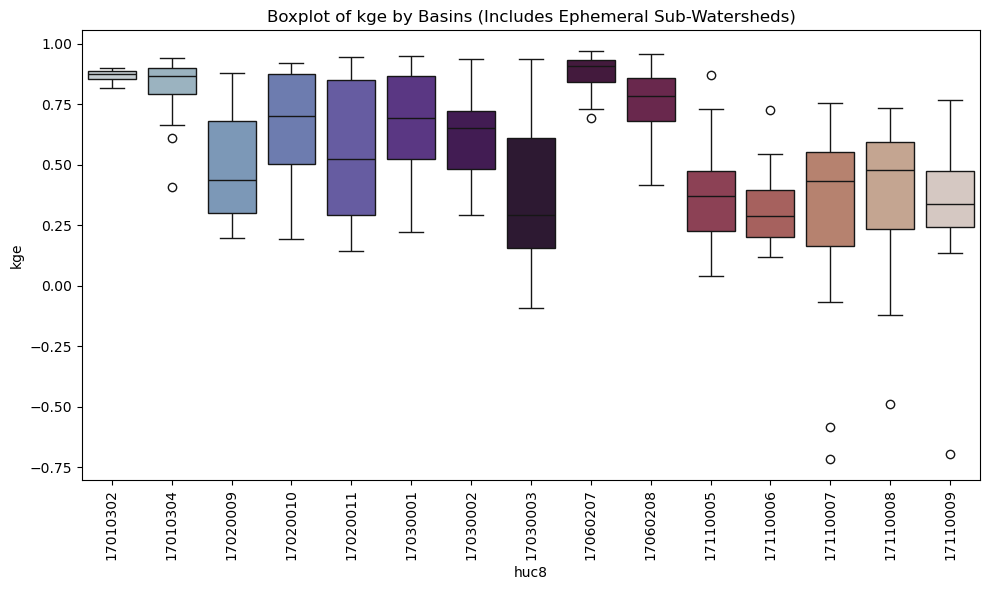

,count,median,mean,std
huc8,,,,
17010302,8,0.872889,0.867922,0.028641
17010304,51,0.865162,0.836130,0.096133
17020009,28,0.437014,0.503221,0.224033
17020010,37,0.699274,0.669451,0.216501
17020011,43,0.524599,0.558937,0.282628
17030001,50,0.693206,0.663480,0.217416
17030002,29,0.649383,0.626124,0.179756
17030003,71,0.293357,0.366765,0.282211
17060207,51,0.905373,0.882981,0.070054


In [23]:
parameter = "kge"
groupby ="huc8"
ttl = f"Boxplot of {parameter} by Basins (Includes Ephemeral Sub-Watersheds)"
plot_boxplot_by_group(filtered_df, parameter, title= ttl, groupby_column = groupby, trunc = True)

/tmp/ipykernel_61501/976335912.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_column, y=parameter, palette=color_map, order=category_order)


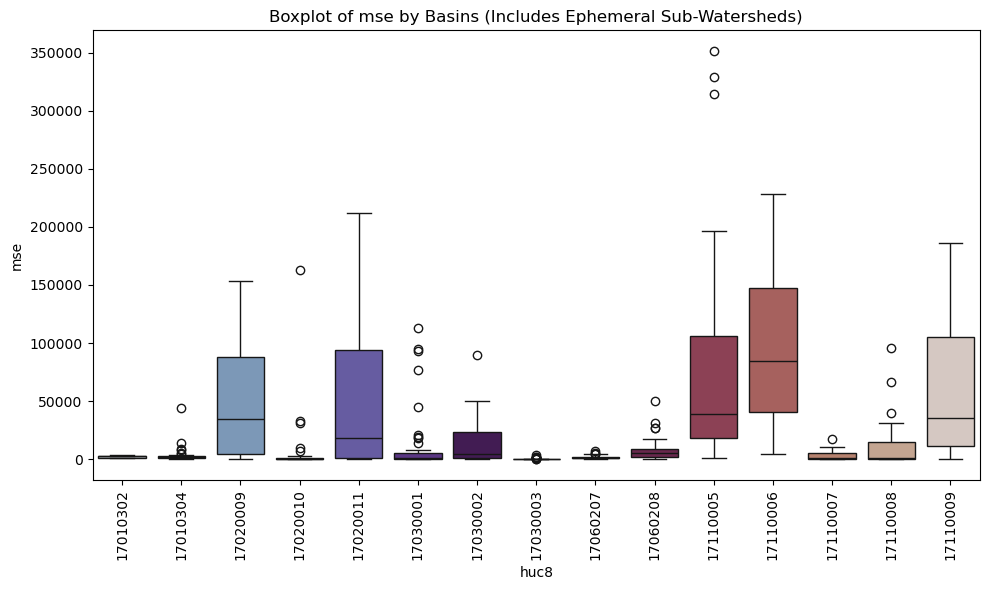

,count,median,mean,std
huc8,,,,
17010302,8,2505.686020,2367.223103,1019.044273
17010304,51,1636.275468,3168.636921,6357.899113
17020009,28,34253.424238,48145.648587,47932.189220
17020010,37,265.933102,7052.375671,27369.142219
17020011,43,18238.397701,53064.132856,66123.530527
17030001,50,902.721693,11053.685001,26276.325435
17030002,29,4181.645801,16098.049179,21162.816598
17030003,71,89.784192,321.449883,570.462607
17060207,51,1243.961988,1765.699335,1466.194662


In [25]:
parameter = "mse"
groupby ="huc8"
ttl = f"Boxplot of {parameter} by Basins (Includes Ephemeral Sub-Watersheds)"
plot_boxplot_by_group(filtered_df, parameter, title= ttl, groupby_column = groupby, trunc = True)

/tmp/ipykernel_61501/976335912.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_column, y=parameter, palette=color_map, order=category_order)


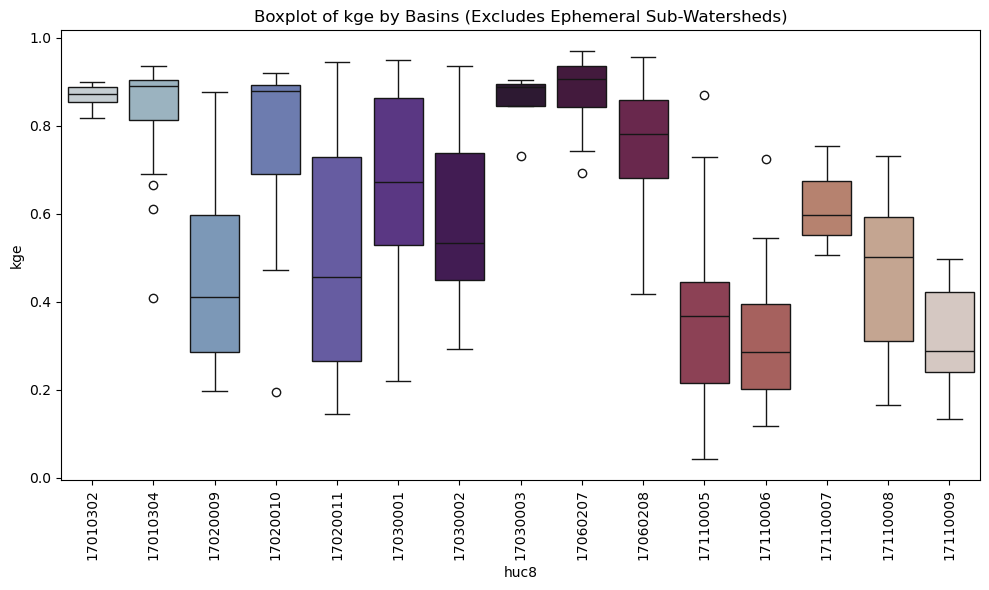

,count,median,mean,std
huc8,,,,
17010302,8,0.872889,0.867922,0.028641
17010304,35,0.889728,0.842230,0.109439
17020009,23,0.410267,0.450146,0.209041
17020010,13,0.879289,0.743126,0.229449
17020011,36,0.456896,0.496674,0.266631
17030001,23,0.673050,0.653945,0.240504
17030002,23,0.532919,0.604197,0.190750
17030003,4,0.887282,0.852647,0.081086
17060207,50,0.905694,0.886020,0.067284


In [24]:
parameter = "kge"
groupby ="huc8"
ttl = f"Boxplot of {parameter} by Basins (Excludes Ephemeral Sub-Watersheds)"
plot_boxplot_by_group(filtered_df_noE, parameter, title= ttl, groupby_column = groupby, trunc = True)

/tmp/ipykernel_61501/976335912.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=groupby_column, y=parameter, palette=color_map, order=category_order)


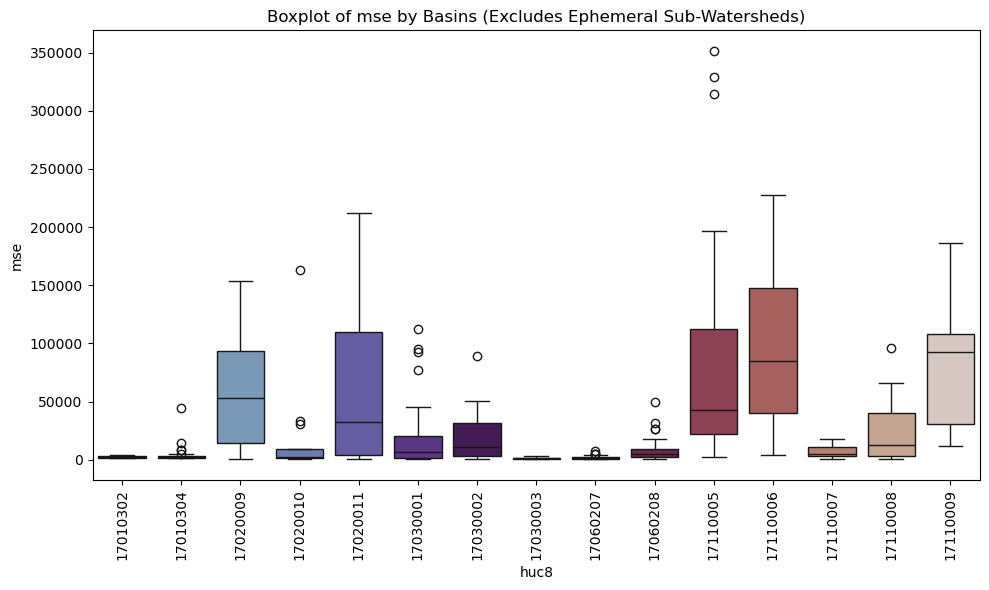

,count,median,mean,std
huc8,,,,
17010302,8,2505.686020,2367.223103,1019.044273
17010304,35,2246.810521,4207.873326,7474.777572
17020009,23,52996.085390,58108.121497,47304.268480
17020010,13,2464.845868,19683.088739,44505.379681
17020011,36,32369.212752,63220.934787,67785.883285
17030001,23,6911.252169,23334.976147,35273.103775
17030002,23,11204.786869,20027.856111,22168.008773
17030003,4,1063.593603,1560.427918,1329.507804
17060207,50,1308.891038,1789.118314,1471.413283


In [26]:
parameter = "mse"
groupby ="huc8"
ttl = f"Boxplot of {parameter} by Basins (Excludes Ephemeral Sub-Watersheds)"
plot_boxplot_by_group(filtered_df_noE, parameter, title= ttl, groupby_column = groupby, trunc = True)

# Step 7 Examine by Elevation 

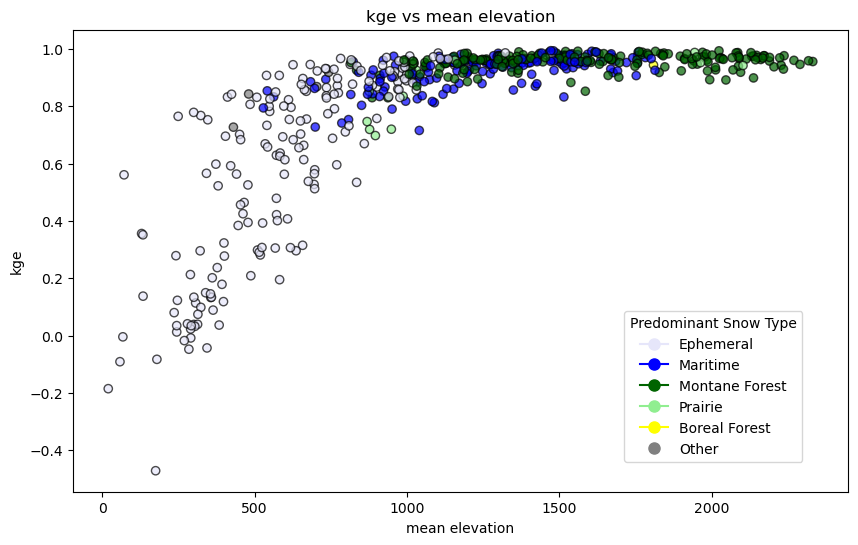

In [82]:
x_var_name = "mean_elevation"
y_var_name = "kge"
ttl = f"{y_var_name}_vs_{x_var_name}"
plot_scatter(df, x_var_name, y_var_name, color_map_snow, title = ttl)


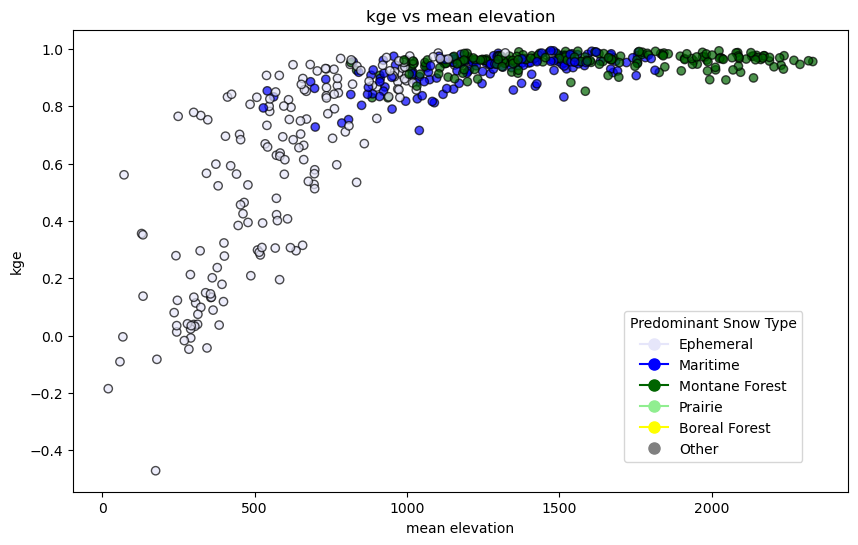

In [85]:
x_var_name = "mean_elevation"
y_var_name = "kge"
ttl = f"{y_var_name}_vs_{x_var_name}"
plot_scatter(filtered_df, x_var_name, y_var_name, color_map_snow, title = ttl)